In [1]:
import warnings
warnings.filterwarnings("ignore")

## Objective: To predict obesity levels based on personal, dietary, and lifestyle attributes.

# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.neighbors import NearestNeighbors 
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap
from sklearn.model_selection import GridSearchCV

# Load Data

| **Variable Name**                | **Type**    | **Description**                                                        |
| -------------------------------- | ----------- | ---------------------------------------------------------------------- |
| `Gender`                         | Categorical | Gender of the individual                                               |
| `Age`                            | Continuous  | Age of the individual                                                  |
| `Height`                         | Continuous  | Height of the individual                                               |
| `Weight`                         | Continuous  | Weight of the individual                                               |
| `family_history_with_overweight` | Binary      | Has a family member suffered or suffers from overweight?               |
| `FAVC`                           | Binary      | Do you eat high caloric food frequently?                               |
| `FCVC`                           | Integer     | Do you usually eat vegetables in your meals?                           |
| `NCP`                            | Continuous  | How many main meals do you have daily?                                 |
| `CAEC`                           | Categorical | Do you eat any food between meals?                                     |
| `SMOKE`                          | Binary      | Do you smoke?                                                          |
| `CH2O`                           | Continuous  | How much water do you drink daily?                                     |
| `SCC`                            | Binary      | Do you monitor the calories you eat daily?                             |
| `FAF`                            | Continuous  | How often do you have physical activity?                               |
| `TUE`                            | Integer     | How much time do you use tech devices (cellphone, TV, computer, etc.)? |
| `CALC`                           | Categorical | How often do you drink alcohol?                                        |
| `MTRANS`                         | Categorical | Which transportation do you usually use?                               |
| `NObeyesdad`                     | Categorical | Obesity level of the individual                                        |



In [7]:
df=pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
data=df.copy()
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


# Data Cleaning 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

 There is no missing value and have 0 values but that values will be considered as data according to details of Column.

In [11]:
df.shape

(2111, 17)

In [12]:
duplicates = df.duplicated()
duplicates.sum()

24

So there are 24 duplicates data which to remove.

In [14]:
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


This are duplicate data with first ocurrence.

In [16]:
df=df.drop_duplicates()
df.shape

(2087, 17)

In [17]:
df.describe(include='all')

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2087,2087.000000,2087.000000,2087.000000,2087,2087,2087.000000,2087.000000,2087,2087,2087.000000,2087,2087.000000,2087.000000,2087,2087,2087
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1052,NaN,NaN,NaN,1722,1844,NaN,NaN,1761,2043,NaN,1991,NaN,NaN,1380,1558,351
mean,NaN,24.353090,1.702674,86.858730,NaN,NaN,2.421466,2.701179,NaN,NaN,2.004749,NaN,1.012812,0.663035,NaN,NaN,NaN
std,NaN,6.368801,0.093186,26.190847,NaN,NaN,0.534737,0.764614,NaN,NaN,0.608284,NaN,0.853475,0.608153,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.915937,1.630178,66.000000,NaN,NaN,2.000000,2.697467,NaN,NaN,1.590922,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.847618,1.701584,83.101100,NaN,NaN,2.396265,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.630866,NaN,NaN,NaN
75%,NaN,26.000000,1.769491,108.015907,NaN,NaN,3.000000,3.000000,NaN,NaN,2.466193,NaN,1.678102,1.000000,NaN,NaN,NaN


# EDA(Exploaratory Data Analysis)

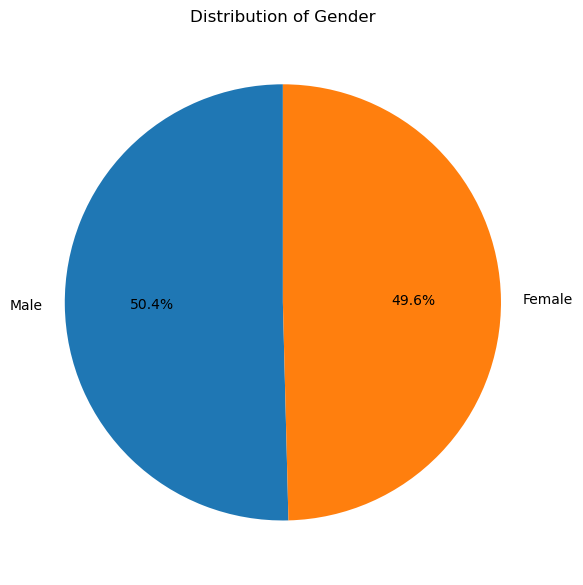

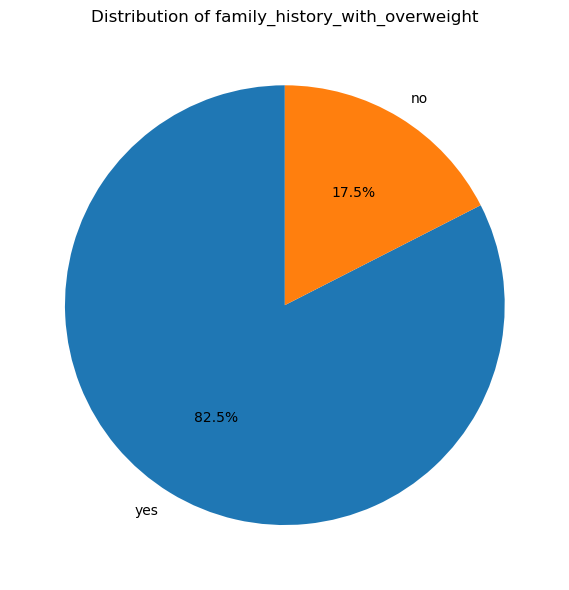

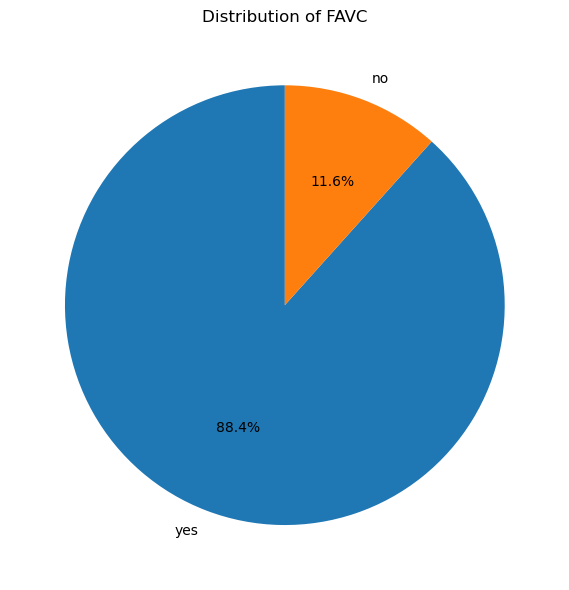

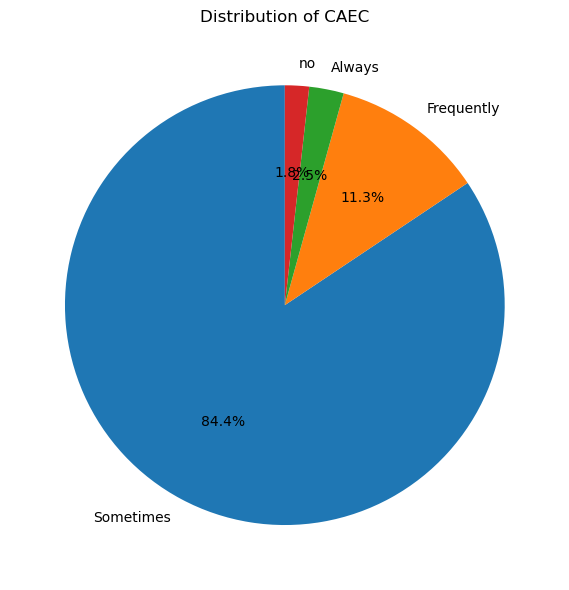

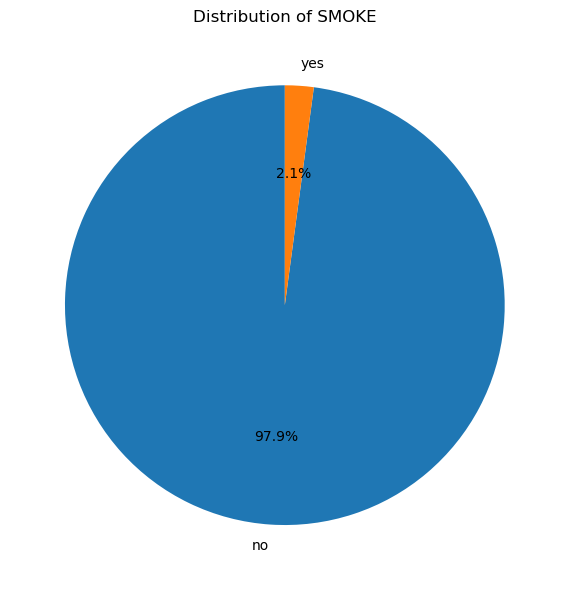

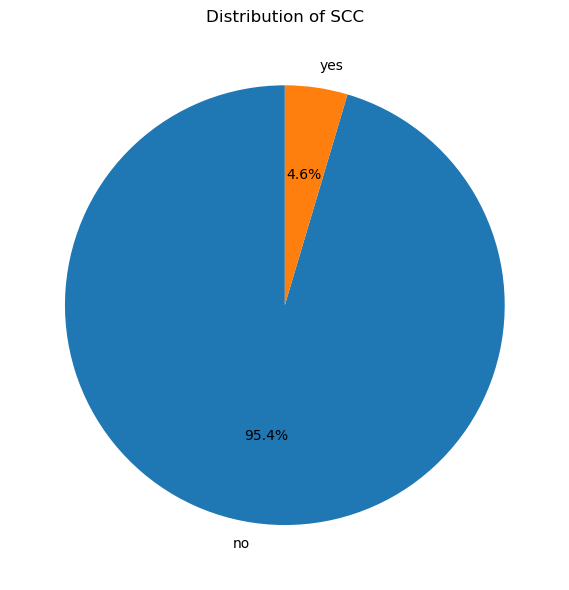

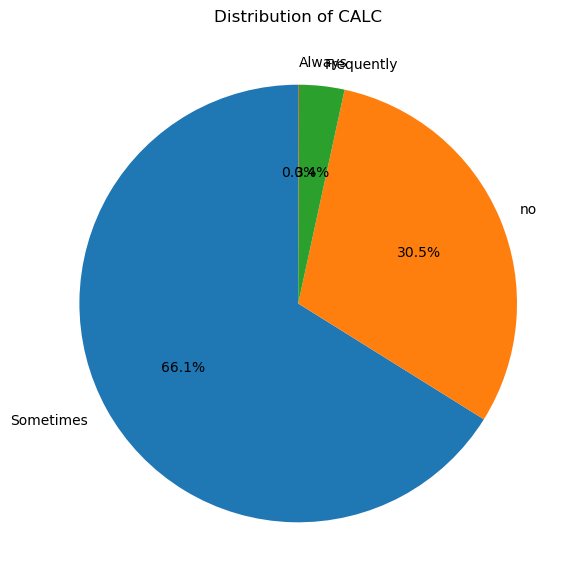

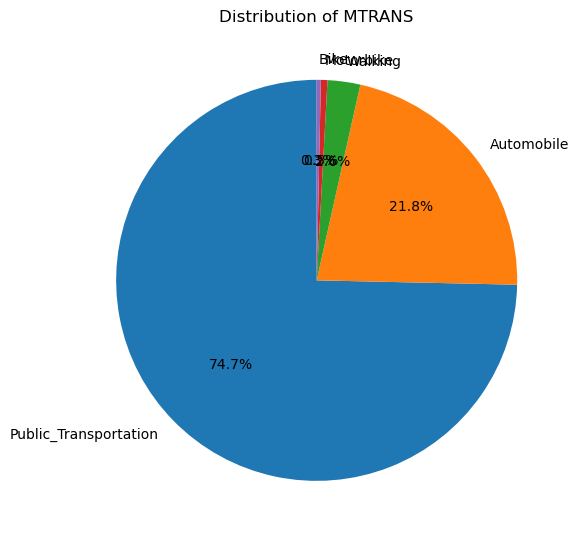

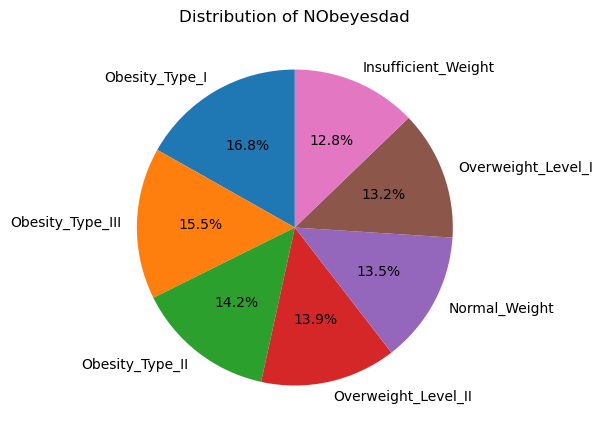

In [19]:
for col in df.select_dtypes(include='object').columns:
    plt.figure(figsize=(6, 6))
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {col}')
    plt.ylabel('') 
    plt.tight_layout()
    plt.show()
    

Distribution of Categorical data to show the proportion of data

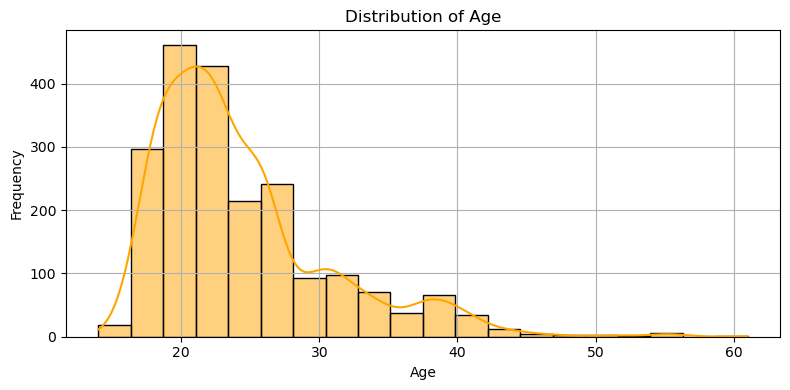

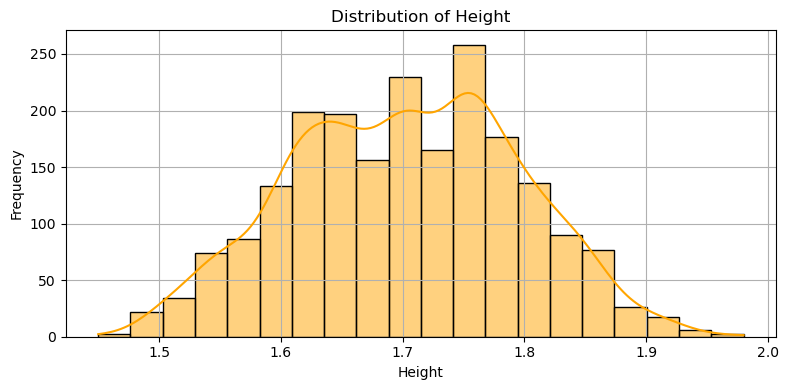

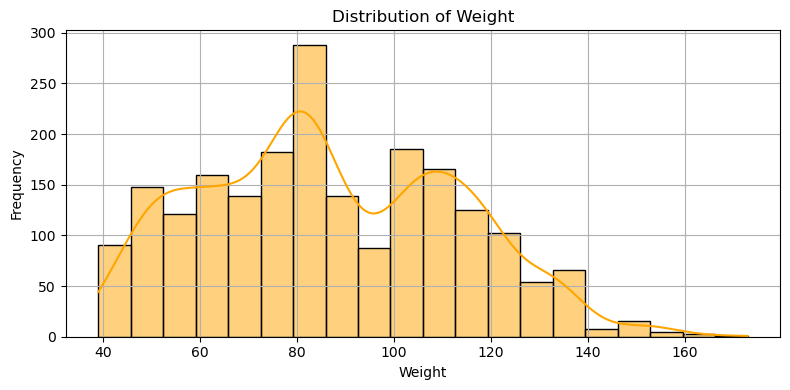

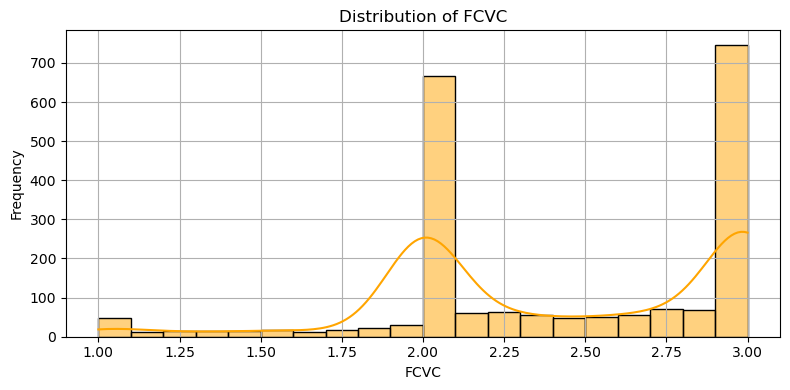

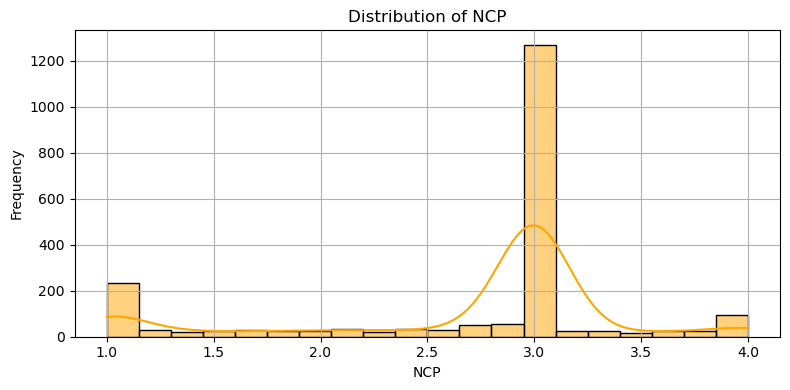

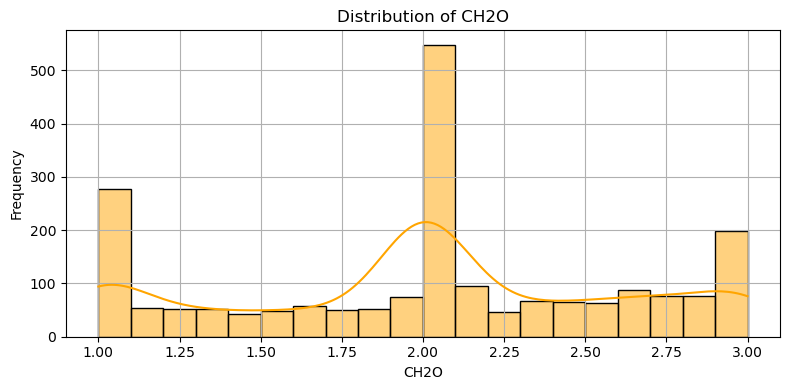

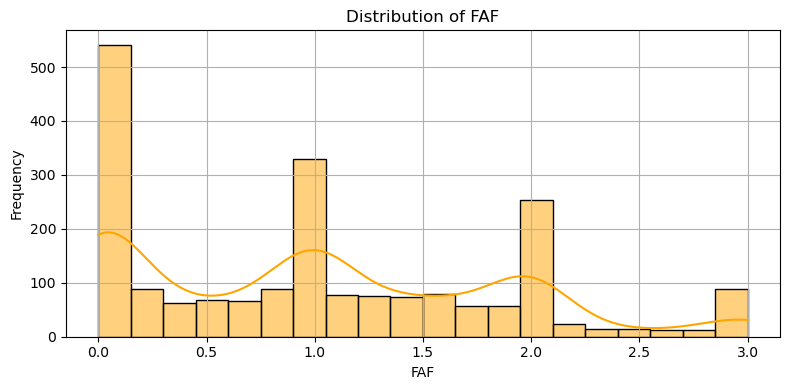

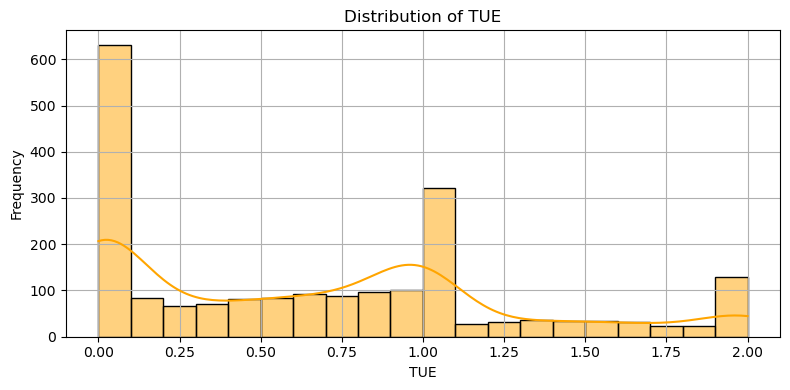

In [21]:
for col in df.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=20, kde=True, color='orange')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Its Showing distribution of data of every numerical column or skewing of the graph.

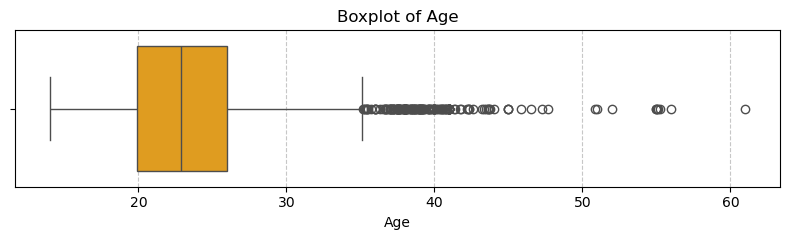

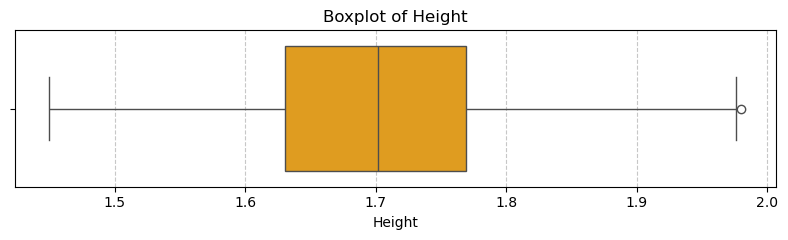

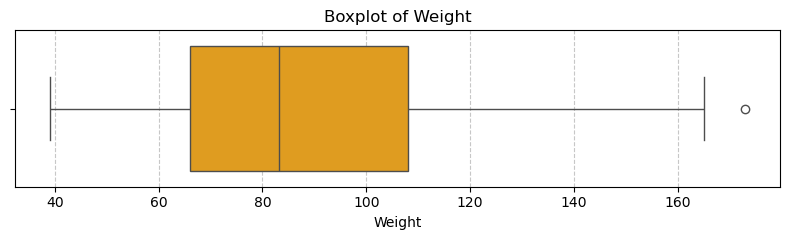

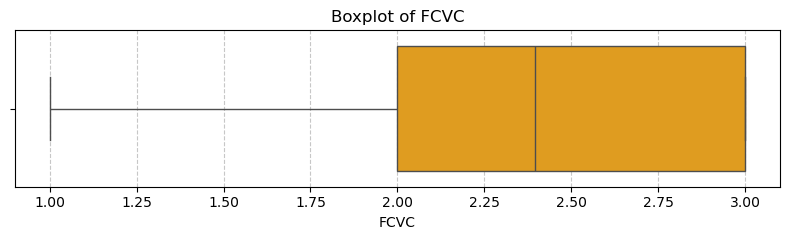

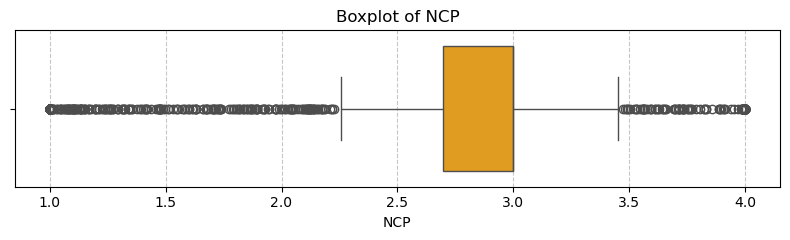

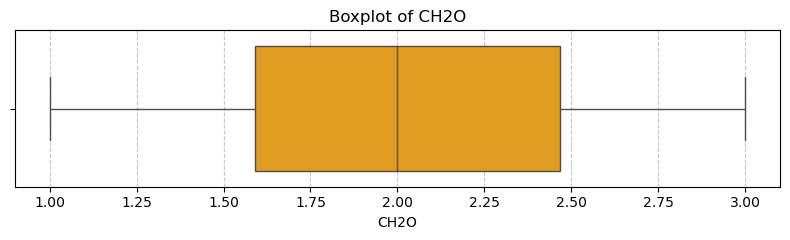

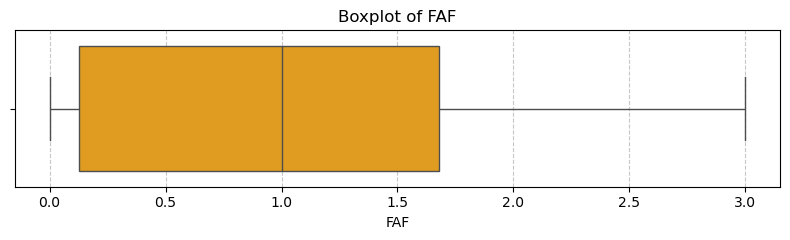

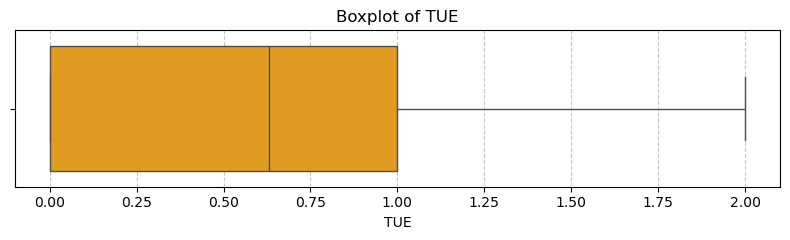

In [23]:
for col in df.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(8, 2.5))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Obs: Age And NCP have many outliers where height and weight few outlier

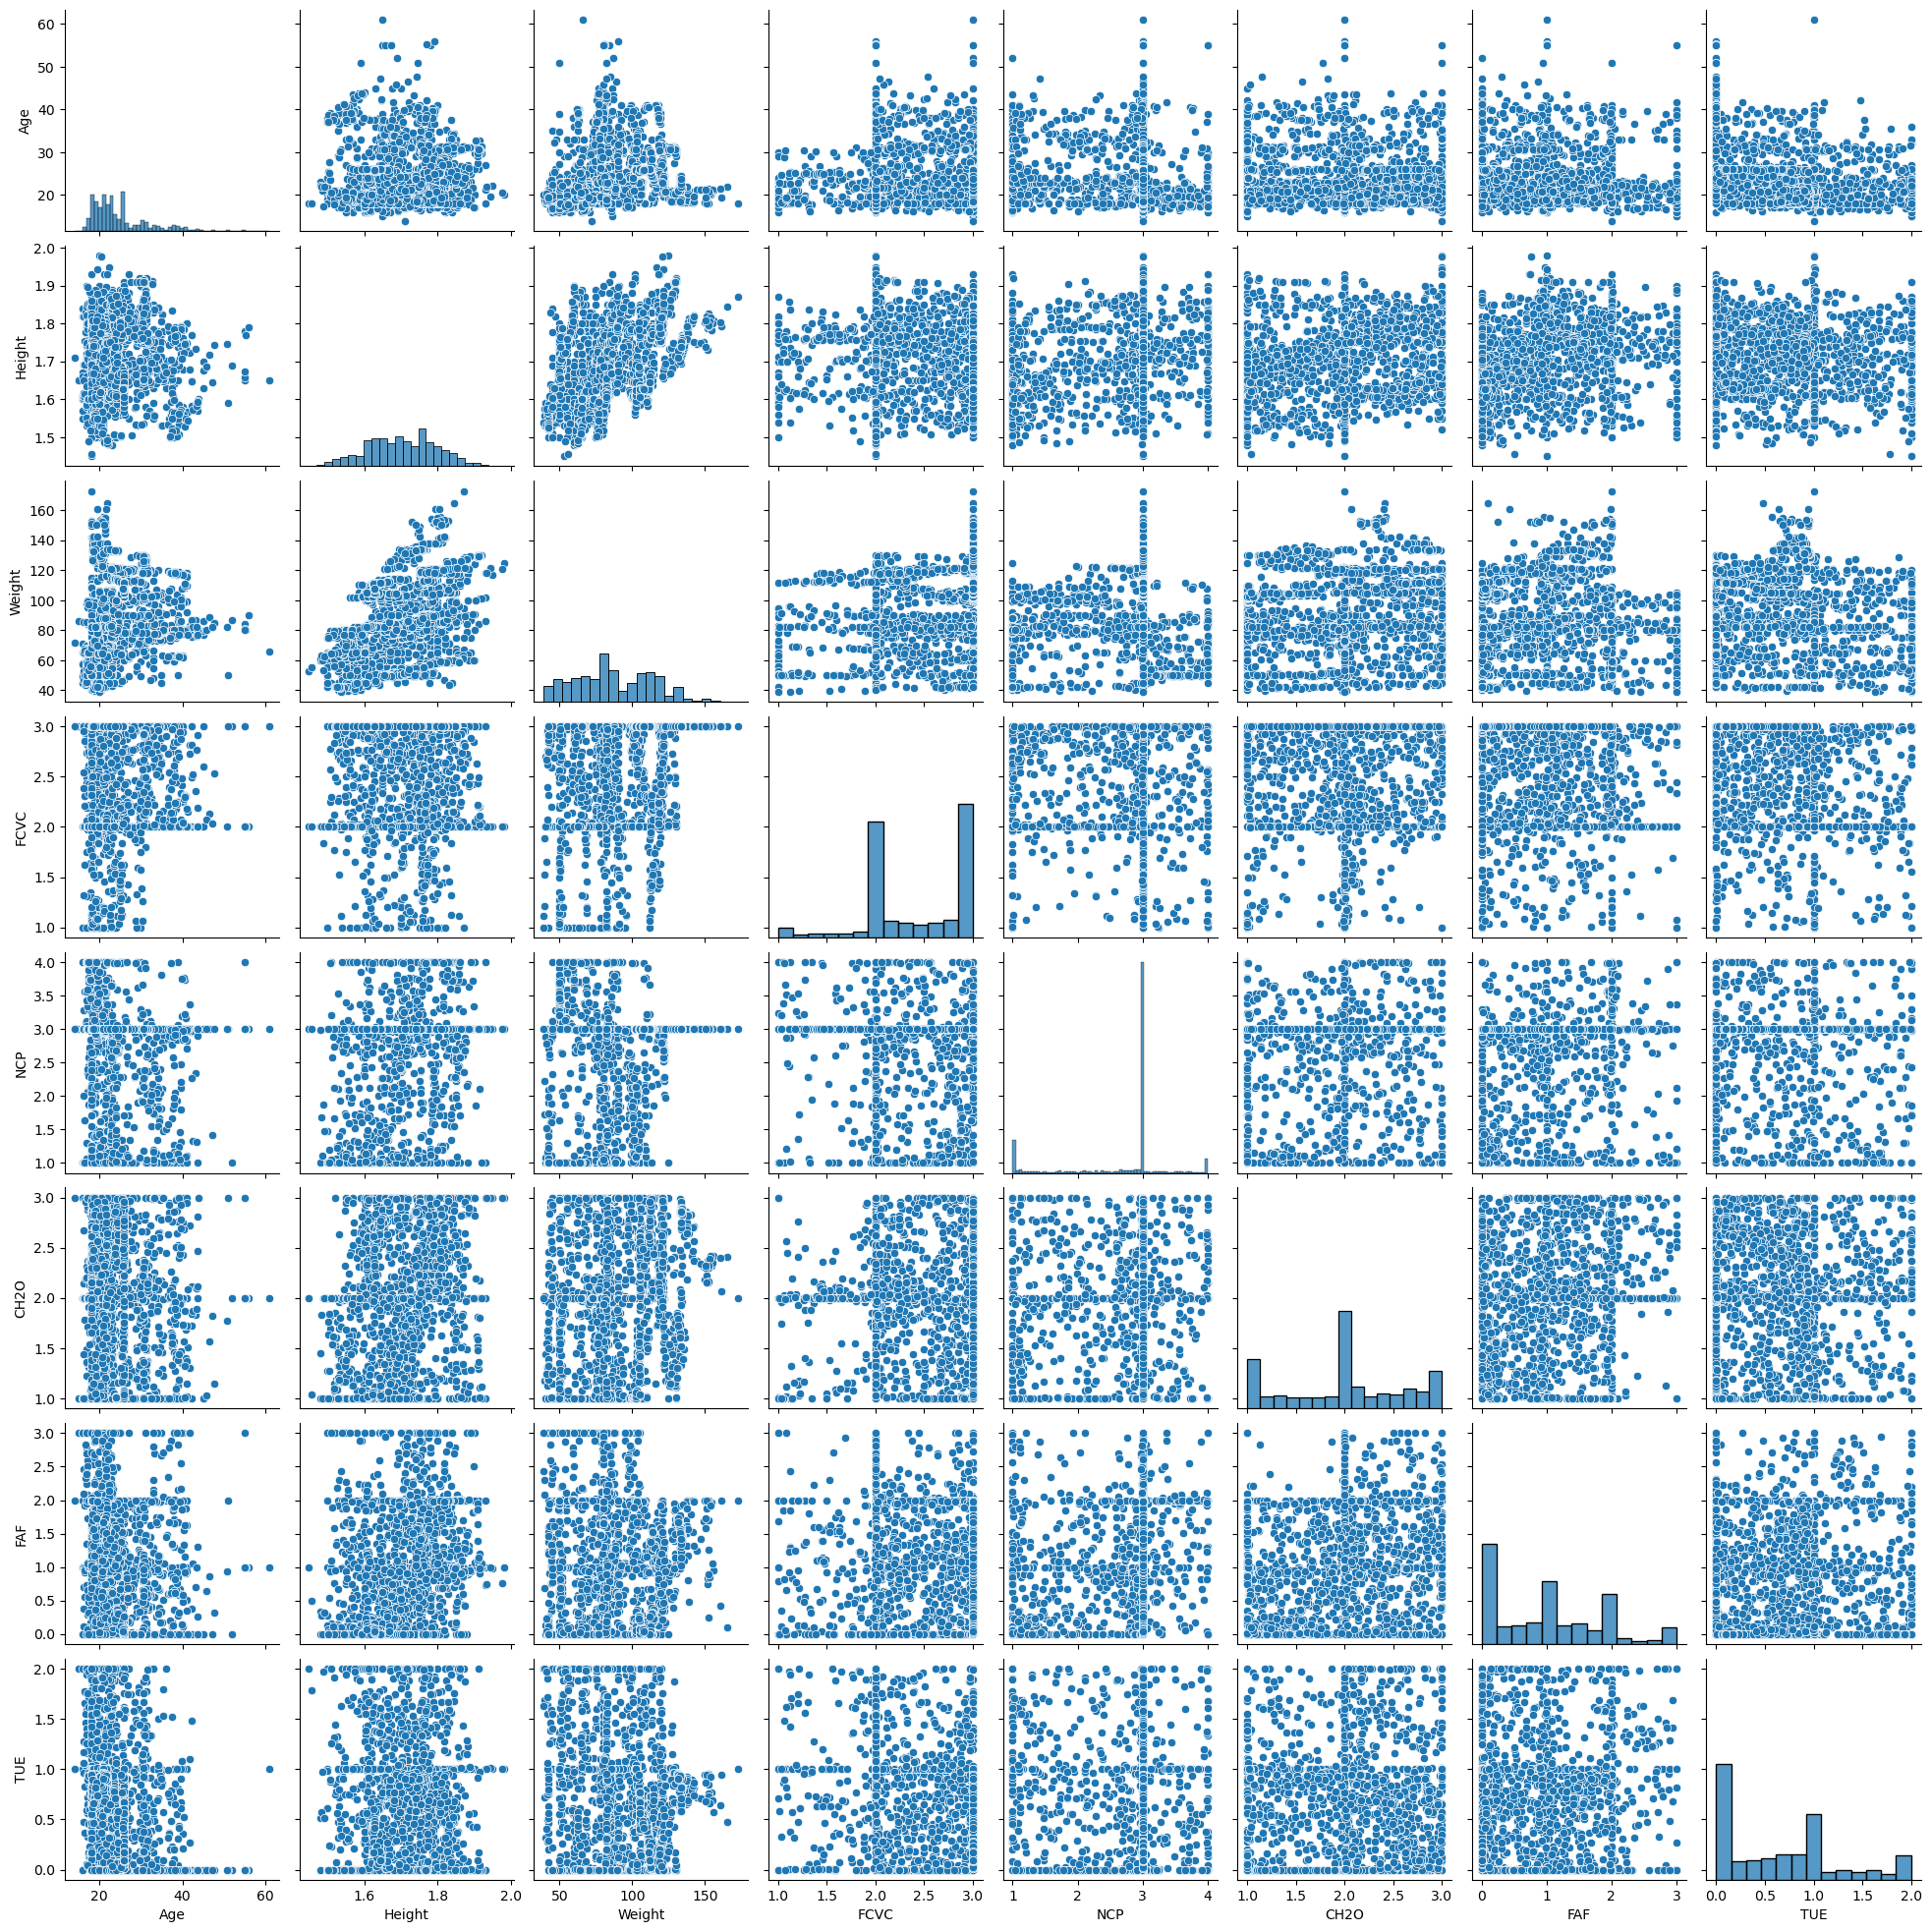

In [25]:
sns.pairplot(df)

obs: As looking this we cannot conclude anything as it is very randomly and diversely spreading in the graph

In [27]:
z_scores = df.select_dtypes(exclude='object').apply(zscore)
z_outliers = (z_scores.abs() > 3)

print("Z-score Outliers per column:")
print(z_outliers.sum())


Z-score Outliers per column:
Age       23
Height     0
Weight     1
FCVC       0
NCP        0
CH2O       0
FAF        0
TUE        0
dtype: int64


In [28]:
iqr_outliers = pd.DataFrame()

for col in df.select_dtypes(exclude='object').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_outliers[col] = ~df[col].between(lower, upper)

print("IQR Outliers per column:")
print(iqr_outliers.sum())


IQR Outliers per column:
Age       167
Height      1
Weight      1
FCVC        0
NCP       577
CH2O        0
FAF         0
TUE         0
dtype: int64


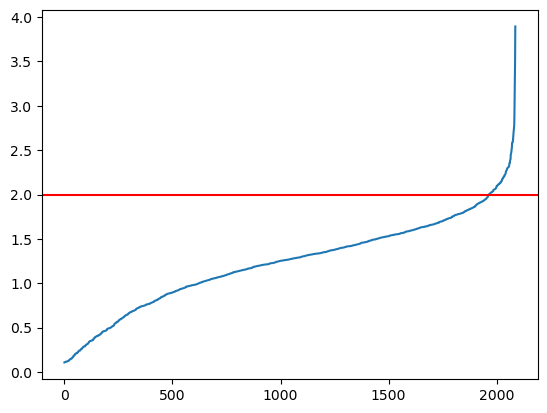

In [29]:
nn = NearestNeighbors(n_neighbors = 10).fit(z_scores)

dist, ind = nn.kneighbors(z_scores)

dist = np.sort(dist,axis =0)[:,9]

plt.plot(dist)
plt.axhline(y=2, color = 'r', ls ='-')

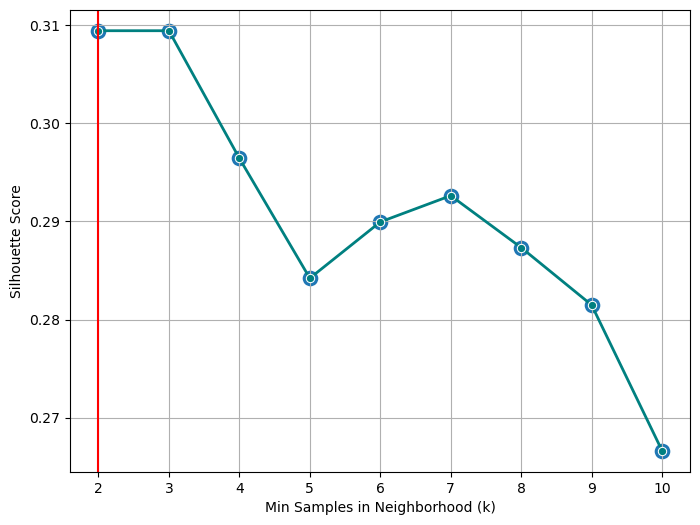

In [30]:
ss = []
for k in range(2, 11):
    dbscan = DBSCAN(eps=2, min_samples= k).fit(z_scores)
    ss.append(silhouette_score(z_scores, dbscan.labels_))

ss_series = pd.Series(ss, index = range(2, 11))

plt.figure(figsize=(8, 6))
ax = sns.lineplot(y = ss_series, x = ss_series.index,marker='o', linewidth=2, color='teal')
ax = sns.scatterplot(y = ss_series, x = ss_series.index, s = 150)
ax = ax.set(xlabel = 'Min Samples in Neighborhood (k)', 
            ylabel = 'Silhouette Score')
plt.axvline(x=2, color='r', linestyle='-')
plt.grid(True)

So i found optimal value esp=2,and k=2

In [32]:
db = DBSCAN(eps=2, min_samples=2)
final_labels = db.fit_predict(z_scores)
display(pd.DataFrame(final_labels).value_counts(normalize=True)*100)
outliers = (final_labels == -1)
print("Number of outliers found:", np.sum(outliers))

0 
 0    99.66459
-1     0.33541
Name: proportion, dtype: float64

Number of outliers found: 7


In [33]:
comparison = pd.DataFrame({
    'Z_score': z_outliers.any(axis=1),
    'IQR': iqr_outliers.any(axis=1),
    'DBSCAN': outliers
})

print("\nOutlier Overlap Summary:")
print(comparison.apply(pd.Series.value_counts))



Outlier Overlap Summary:
       Z_score   IQR  DBSCAN
False     2063  1388    2080
True        24   699       7


Obs: Among Z-score, IQR, and DBSCAN methods, DBSCAN is best suited for this dataset due to its ability to detect multivariate and structural outliers, so I will use it to remove the outliers.

In [35]:
df = df[final_labels!=-1]
df.shape

(2080, 17)

In [36]:
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [37]:
cat_column=df.select_dtypes(include='object').columns.tolist()
cat_column

['Gender',
 'family_history_with_overweight',
 'FAVC',
 'CAEC',
 'SMOKE',
 'SCC',
 'CALC',
 'MTRANS',
 'NObeyesdad']

In [38]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [39]:
for col in cat_column:
    if col!="NObeyesdad":
        print(f"\nCrosstab of {col} vs NObeyesdad:")
        res=pd.crosstab(df[col],df['NObeyesdad'], normalize='index')
        display(res)


Crosstab of Gender vs NObeyesdad:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Gender,,,,,,,
Female,0.163919,0.129971,0.150339,0.001940,0.313288,0.140640,0.099903
Male,0.093422,0.137274,0.185891,0.280267,0.000953,0.123928,0.178265



Crosstab of family_history_with_overweight vs NObeyesdad:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history_with_overweight,,,,,,,
no,0.390110,0.354396,0.019231,0.002747,0.000000,0.184066,0.049451
yes,0.072844,0.086830,0.199883,0.171911,0.188811,0.121212,0.158508



Crosstab of FAVC vs NObeyesdad:


...

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SCC,,,,,,,
no,0.123364,0.125378,0.175227,0.148540,0.163142,0.120342,0.144008
yes,0.234043,0.308511,0.021277,0.010638,0.000000,0.382979,0.042553



Crosstab of CALC vs NObeyesdad:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CALC,,,,,,,
Always,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Frequently,0.014925,0.253731,0.208955,0.014925,0.000000,0.223881,0.283582
Sometimes,0.108128,0.113933,0.124819,0.162554,0.234398,0.152395,0.103774
no,0.184543,0.162461,0.258675,0.111987,0.001577,0.078864,0.201893



Crosstab of MTRANS vs NObeyesdad:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
MTRANS,,,,,,,
Automobile,0.101322,0.096916,0.240088,0.207048,0.002203,0.145374,0.207048
Bike,0.000000,0.571429,0.000000,0.142857,0.000000,0.285714,0.000000
Motorbike,0.000000,0.545455,0.272727,0.000000,0.000000,0.090909,0.090909
Public_Transportation,0.138353,0.124196,0.151866,0.128700,0.207851,0.127413,0.121622
Walking,0.111111,0.574074,0.037037,0.018519,0.000000,0.148148,0.111111


#### OBS

1. Gender

Females have a high proportion in Obesity_Type_III (31%), suggesting more severe obesity cases.

Males show higher representation in Obesity_Type_II (28%) and Obesity_Type_I (18%).

Obesity Type III is more common in females; Type II more in males.

2. Family History of Overweight

Those with no family history are mostly Normal or Insufficient Weight (around 74%).

Those with yes, show higher obesity levels — especially Type I, II, and III (~56%).

Family history is strongly linked to higher obesity risk.

3. FAVC (Frequent consumption of high-calorie food)

Those answering “no” are mostly Normal or Insufficient Weight (52%).

Those answering “yes” have higher proportions of all obesity types, particularly Type I, II, III.

High-calorie food intake correlates with higher obesity categories.

4. CAEC (Consumption of food between meals)

“Frequently” and “Sometimes” snacking shows strong links to Obesity_Type_I/II/III.

“No” snacking leads to higher Overweight_Level_I (57%), but not necessarily obesity.

Occasional or frequent snacking contributes to obesity development; no snacking more linked to overweight than obesity.

5. SMOKE

Smokers have higher Obesity_Type_II (35%), and lower Insufficient/Normal weight.

Non-smokers are spread out but more balanced.

Smoking appears linked with higher Obesity_Type_II risk, but more data needed to confirm causality.

6. SCC (Calories monitoring)

Those who monitor (yes): Mostly Normal Weight (31%) or Overweight_Level_I (38%).

Those who don’t have more obesity across all types.

Monitoring calorie intake is associated with healthier weight control.

7. CALC (Alcohol Consumption)

“Always” drinkers are 100% Normal Weight — likely due to very small sample size.

“Frequently”/“Sometimes” drinkers are spread across obesity types, especially Type I/II/III.

Non-drinkers also show high obesity rates (especially Type I, Overweight).

Alcohol alone isn’t clearly indicative; patterns suggest moderate drinking may correlate with obesity.

8. MTRANS (Transportation method)

Public Transport and Automobile users show higher obesity (Type I–III and Overweight).

Bike, Walking, Motorbike users are more likely to be Normal Weight.

Active transportation (walking/biking) is linked to lower obesity.

Conclusion:

Family history, frequent snacking, high-calorie food, and inactive transport methods are strong risk factors for obesity.

Monitoring food/calorie intake and active lifestyle choices like walking/biking are protective.

In [41]:
for col in cat_column:
    print(f"\nColumn: {col}")
    print("Total values:", df[col].value_counts())


Column: Gender
Total values: Gender
Male      1049
Female    1031
Name: count, dtype: int64

Column: family_history_with_overweight
Total values: family_history_with_overweight
yes    1716
no      364
Name: count, dtype: int64

Column: FAVC
Total values: FAVC
yes    1840
no      240
Name: count, dtype: int64

Column: CAEC
Total values: CAEC
Sometimes     1756
Frequently     235
Always          52
no              37
Name: count, dtype: int64

Column: SMOKE
Total values: SMOKE
no     2038
yes      42
Name: count, dtype: int64

Column: SCC
Total values: SCC
no     1986
yes      94
Name: count, dtype: int64

Column: CALC
Total values: CALC
Sometimes     1378
no             634
Frequently      67
Always           1
Name: count, dtype: int64

Column: MTRANS
Total values: MTRANS
Public_Transportation    1554
Automobile                454
Walking                    54
Motorbike                  11
Bike                        7
Name: count, dtype: int64

Column: NObeyesdad
Total values: NObeye

# Encoding Data

Label Encoding Used for :— 

family_history_with_overweight, FAVC, SMOKE, SCC:
Binary (Yes/No), so 0 and 1 are enough

CAEC, CALC:
Have natural order (e.g., no < sometimes < frequently)

NObeyesdad (target):
Multi-class labels for classification

One-Hot Encoding Used for :— 

Gender, MTRANS:
Nominal categories with no order (e.g., Male/Female, transport types)

In [44]:
label_encode_cols = [
    'family_history_with_overweight',  
    'FAVC',                            
    'SMOKE',                            
    'SCC',                           
    'CAEC',                             
    'CALC',                             
    'NObeyesdad'    
]

one_hot_encode_cols = [
    'Gender',     
    'MTRANS'      
]

In [45]:
le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col])

In [46]:
df = pd.get_dummies(df, columns=one_hot_encode_cols, drop_first=True)

# Feature Selection

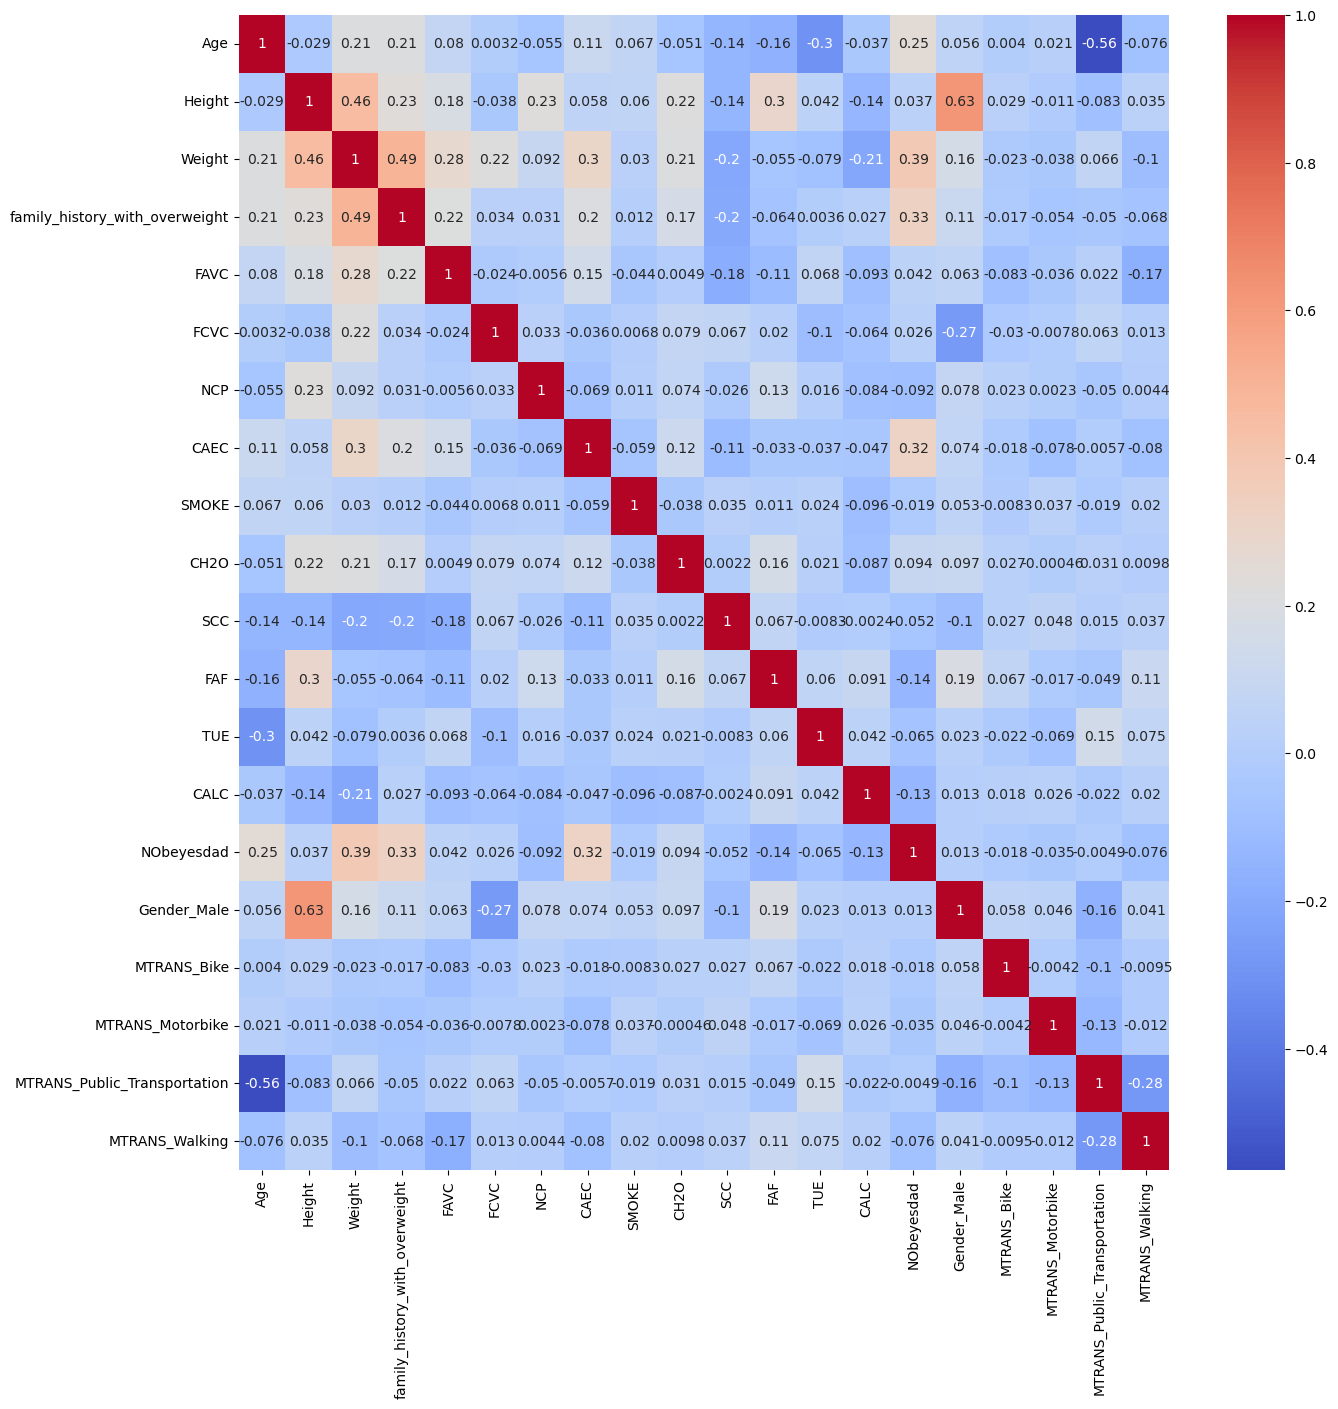

In [48]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Most important features for predicting obesity:

1.Weight

2.family_history_with_overweight

3.FAVC (high-calorie food)

4.Age

5.Gender_Male

Height has a negative relation with obesity — taller people tend to be less obese.

Some features like SCC, SMOKE, CH2O, CALC, and MTRANS have very weak correlation, so they may not help much in prediction.

No strong multicollinearity — features are not highly related to each other

But We can conclude any thing as because of data is very multivariate  correlation doesnot help that so much.

In [50]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']


mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=99)


mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("Top features by Mutual Information:")
mi_series.head(11)


Top features by Mutual Information:


Weight                            1.264141
Age                               0.580849
Height                            0.415270
FCVC                              0.386240
CH2O                              0.298201
FAF                               0.293042
NCP                               0.259905
TUE                               0.259808
Gender_Male                       0.196652
family_history_with_overweight    0.153914
CAEC                              0.138709
dtype: float64

Weight is the most informative feature (MI = 1.26) — strongly linked to obesity classification.

Age and Height are also highly predictive, showing the importance of basic body metrics.

Lifestyle and behavior-related features like:

FCVC (vegetable intake),

CH2O (water intake),

FAF (physical activity),

NCP (number of meals),

TUE (technology use)

all contribute significantly to predicting obesity levels.

Gender_Male and family_history_with_overweight carry meaningful signal, though slightly lower than numeric features.

CAEC (eating between meals) also shows predictive value and should be retained.

In [52]:
selected_features=['Weight','Age','Height','FCVC','CH2O','FAF','NCP','TUE','Gender_Male','family_history_with_overweight','CAEC']

# Splitting Data

In [54]:
X = df[selected_features]
y = df['NObeyesdad']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=99, stratify=y
)

In [55]:
display(X_train.shape)
display(y_train.shape)
display(X_test.shape)
display(y_test.shape)

(1664, 11)

(1664,)

(416, 11)

(416,)

# Evaluate and Train the Data with Different Model

In [57]:
def evaluate_model(name, model, X_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    return [name, acc, prec, rec, f1]


In [58]:
def run_all_models(X_train, X_test, label=""):
    models = [
        ("Logistic Regression", LogisticRegression(max_iter=1000)),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("SVM (RBF)", SVC(kernel='rbf')),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        ("Naive Bayes", GaussianNB()),
        ("XGBoost Classification", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=99))
    ]
    
    results = []
    for name, model in models:
        results.append(evaluate_model(f"{name} {label}", model, X_train, X_test))
    return results

In [59]:
res= run_all_models(X_train, X_test)

all_results = pd.DataFrame(res,
                           columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

print("\nFINAL COMPARISON:\n")
display(all_results.sort_values(by='F1 Score', ascending=False))



FINAL COMPARISON:



,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost Classification,0.973558,0.973250,0.971960,0.972241
1,Random Forest,0.947115,0.949483,0.944338,0.944939
3,KNN,0.862981,0.871052,0.856283,0.850592
0,Logistic Regression,0.778846,0.765671,0.770983,0.762957
4,Naive Bayes,0.641827,0.622605,0.638961,0.614597
2,SVM (RBF),0.617788,0.631080,0.618696,0.605049


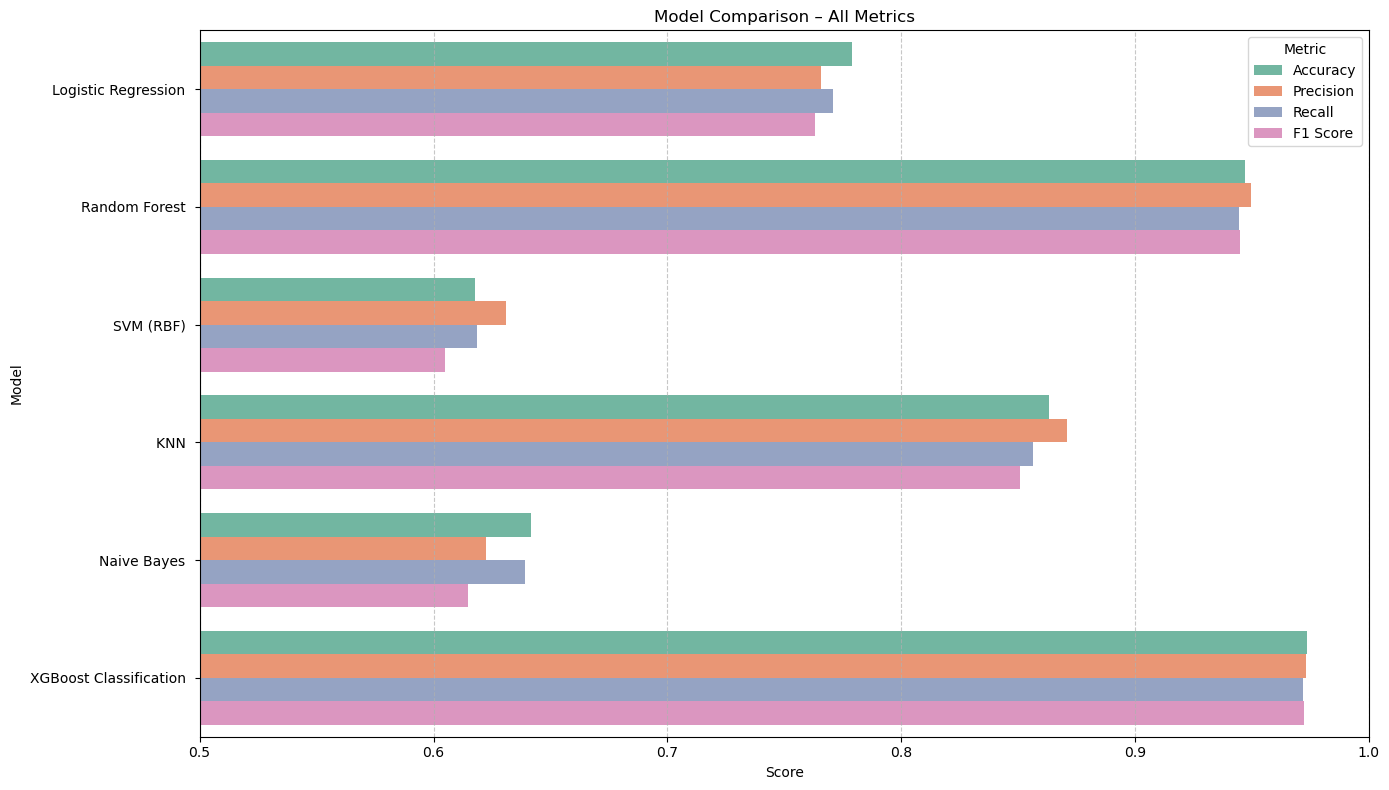

In [60]:
metrics_melted = all_results.melt(id_vars='Model', 
                                   value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                                   var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(data=metrics_melted, x='Score', y='Model', hue='Metric', palette='Set2')

plt.title('Model Comparison – All Metrics')
plt.xlabel('Score')
plt.ylabel('Model')
plt.xlim(0.5, 1.0)
plt.legend(title='Metric')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

After evaluating multiple classification models on Accuracy, Precision, Recall, and F1 Score, XGBoost Classifier clearly performed the best across all metrics, achieving over 97% in every category.

It consistently outperformed other models like Random Forest, Logistic Regression, and KNN. This shows that XGBoost is very effective at capturing complex patterns and handling multi-class classification problems.

Therefore, I selected XGBoost as the final model for this project because:

-It provides high accuracy and balanced performance

-It handles non-linear relationships well

-It’s robust against overfitting due to its boosting mechanism

The grouped bar chart above clearly shows XGBoost has the highest scores in every metric, making it the most reliable and powerful choice.


Confusion Matrix: Logistic Regression


<Figure size 500x700 with 0 Axes>

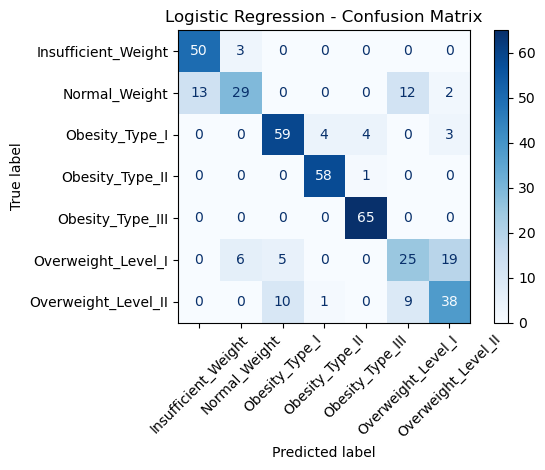


Confusion Matrix: Random Forest


<Figure size 500x700 with 0 Axes>

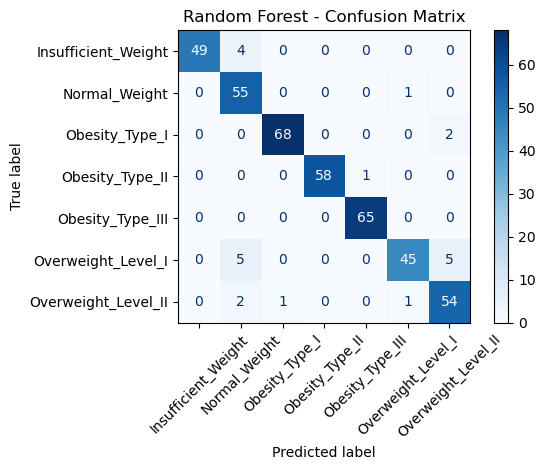


Confusion Matrix: SVM (RBF)


<Figure size 500x700 with 0 Axes>

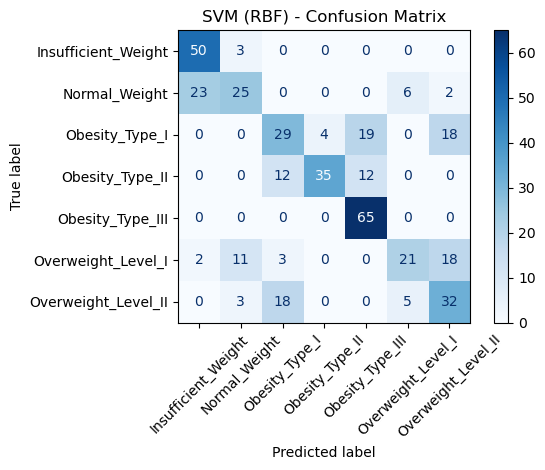


Confusion Matrix: KNN


<Figure size 500x700 with 0 Axes>

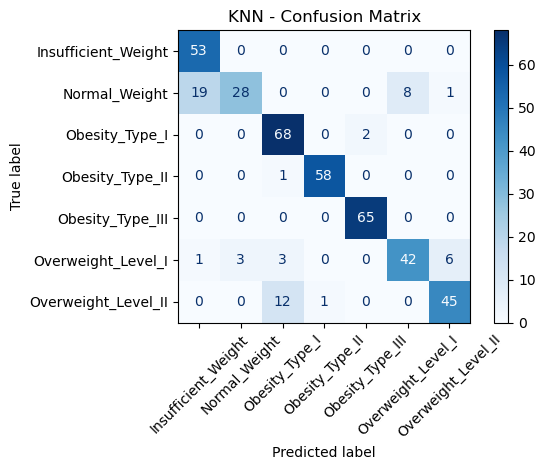


Confusion Matrix: Naive Bayes


<Figure size 500x700 with 0 Axes>

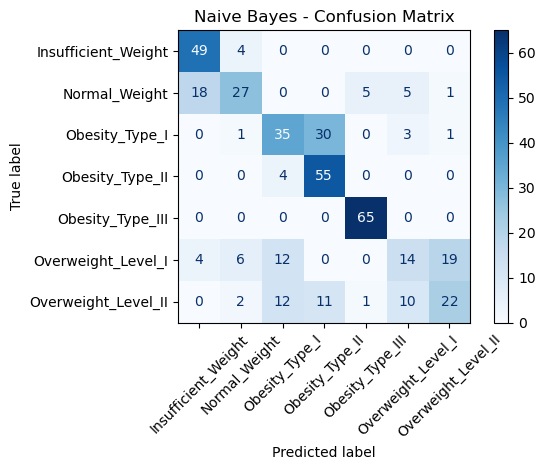


Confusion Matrix: XGBoost Classification


<Figure size 500x700 with 0 Axes>

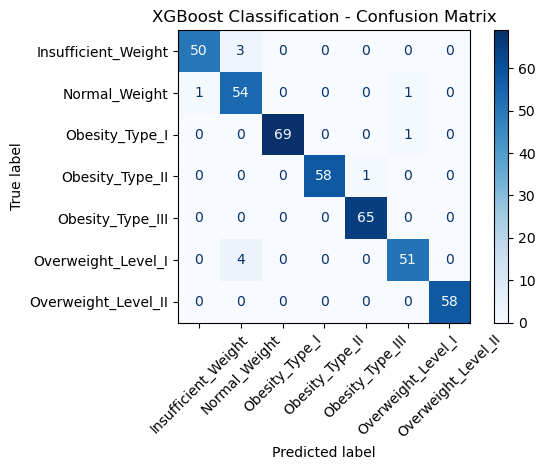

In [62]:
models = [
        ("Logistic Regression", LogisticRegression(max_iter=1000)),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
        ("SVM (RBF)", SVC(kernel='rbf')),
        ("KNN", KNeighborsClassifier(n_neighbors=5)),
        ("Naive Bayes", GaussianNB()),
        ("XGBoost Classification", XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=99))
]


for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    
    print(f"\nConfusion Matrix: {name}")
    plt.figure(figsize=(5, 7))
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()


Observation:

We have to observe the values that are not on the diagonal, as they show the mistakes made by the model — where it predicted the wrong class.

Each row represents the actual (true) class.

Each column represents the predicted class.

Values on the diagonal show the number of correct predictions for each class.

Values off the diagonal show where the model misclassified the data.

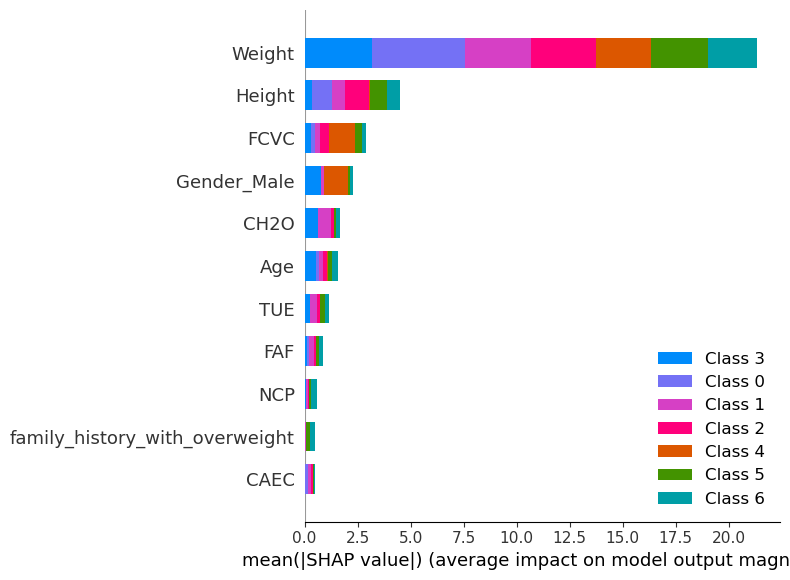

In [64]:
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=99)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

The SHAP analysis shows that Weight is the most influential feature in predicting obesity levels. It has the highest impact across all obesity classes, which makes sense as weight is directly related to body fat and obesity.

The next most important feature is Height, followed by FCVC (frequency of vegetable consumption) and Gender. These features together help the model understand healthy vs unhealthy lifestyle patterns.

Other factors like water intake (CH2O), Age, and Technology Use (TUE) also play a moderate role. They likely reflect daily habits and health routines.

Features like physical activity (FAF), number of meals (NCP), snacking (CAEC), and family history have relatively low impact in this model but may still help in classifying borderline cases.

Overall, the SHAP plot confirms that the model mostly relies on physical measurements and healthy behavior features to make accurate obesity predictions.



# Tuning

In [67]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=99)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}


grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy', 
    verbose=1,
    n_jobs=-1 
)


grid_search.fit(X_train, y_train)


print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1}
Best Accuracy Score: 0.9669398313976627


obs:

The model performs consistently well across different splits, confirming it generalizes well.

A relatively deeper tree (max_depth=5) and faster learning rate (0.2) worked best for this dataset.

Using all features (colsample_bytree=1) and full dataset sampling (subsample=1) improved model learning.

# Predict The Value with an Example

In [70]:
best_xgb_model = grid_search.best_estimator_

In [71]:
example = pd.DataFrame([{
    'Weight': 85,
    'Age': 22,
    'Height': 1.75,
    'FCVC': 3.0,
    'CH2O': 2.0,
    'FAF': 1.0,
    'NCP': 3.0,
    'TUE': 1.0,
    'Gender_Male': 1,
    'family_history_with_overweight': 1,
    'CAEC': 2
}])

# Predict
pred = best_xgb_model.predict(example)
decoded = le.inverse_transform(pred)[0]

print("Predicted Class:", decoded)


Predicted Class: Overweight_Level_II


# Project Summary Report

### **Objective:**

To predict obesity levels based on personal, dietary, and lifestyle attributes.

---

### **Steps Performed**

---

#### **1. Imported Required Libraries**

---

#### **2. Data Cleaning**

* Removed duplicates.
* Checked and confirmed there are no missing values.

---

#### **3. Exploratory Data Analysis**

* Plotted pie charts, distribution plots, and boxplots.
* Reviewed descriptive statistics to understand the data.
* Understood feature distributions and categorical proportions.
* Detected outliers and removed them using **DBSCAN** due to its ability to detect **multivariate and structural outliers**.

---

#### **4. Encoding**

* Applied **Label Encoding** for binary features (e.g., Gender).
* Applied **One-Hot Encoding** for multi-category features (e.g., Transportation).

---

#### **5. Feature Selection**

* Used **Mutual Information** to select the most important features.

**Final selected features:**

* `'Weight'`, `'Age'`, `'Height'`, `'FCVC'`, `'CH2O'`, `'FAF'`, `'NCP'`, `'TUE'`, `'Gender_Male'`,
  `'family_history_with_overweight'`, `'CAEC'`.

---

#### **6. Model Training and Evaluation**

* Trained models:

  * Logistic Regression
  * Random Forest
  * SVM
  * KNN
  * Naive Bayes
  * XGBoost

* Compared models using:

  * Accuracy
  * Precision
  * Recall
  * F1 Score

---

### **Final Conclusion:**

After comparison, **XGBoost Classifier** was selected as the final model.

---

### **Why I Selected XGBoost Classifier**

* **Highest Accuracy:** 97.35% — significantly better than other models
* **Balanced Metrics:** Precision, Recall, and F1 Score all above 97%
* **Robust to noise and outliers**
* **Efficient with multiclass classification**
* **Less overfitting** due to its boosting mechanism

---

After model selection, I performed **SHAP Analysis** to understand **feature influence** on each prediction class.

---

### **Hyperparameter Tuning (Next Step)**

---

#### **Why I Used It**

To explore:

* Whether the model can perform even better
* How well it generalizes to unseen data
* Reduce overfitting/underfitting by finding the best values for:

  * `max_depth`, `learning_rate`, `n_estimators`, etc.

---

#### **Why It Matters**

* Default values aren’t always optimal for every dataset
* Tuning improves performance, especially for minority classes
* Better precision, recall, and general reliability

---

### **Why Accuracy Went Down After Tuning**

- The reason accuracy is lower after tuning is because the default model used only one train-test split, which can sometimes give an **optimistic result**.

- **Hyperparameter tuning with GridSearchCV** uses **cross-validation** — evaluating the model on **multiple data splits** and averaging the results.

- This gives a **more reliable and realistic estimate of model performance**, and helps ensure the model generalizes well to **unseen data**.


`Atlast` ,I am also showing an example by predicting with some values as my model trained and performed well.

This is all my learning and finding i do for this model And try to explore all methods which can be helpful .

Thank you.